In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
simuls = pd.read_csv("results_mean.csv")
data_long = simuls.melt(
    id_vars=[c for c in simuls.columns if not c.startswith("Precision_quantile_")],
    value_vars=[c for c in simuls.columns if c.startswith("Precision_quantile_")],
    var_name="combined",
    value_name="Precision"
)

data_long[["Metric", "Quantile"]] = data_long["combined"].str.extract(r"(.*)_quantile_(.*)")
data_long["Quantile"] = data_long["Quantile"].astype(float).round(4)
data_long = data_long.drop(columns="combined")

In [26]:
data_long_recall = simuls.melt(
    id_vars=[c for c in simuls.columns if not c.startswith("Recall_quantile_")],
    value_vars=[c for c in simuls.columns if c.startswith("Recall_quantile_")],
    var_name="combined",
    value_name="Recall"
)

data_long_recall[["Metric", "Quantile"]] = data_long_recall["combined"].str.extract(r"(.*)_quantile_(.*)")
data_long_recall["Quantile"] = data_long_recall["Quantile"].astype(float).round(4)
data_long_recall = data_long_recall.drop(columns="combined")

In [27]:
merge_keys = ["Quantile", "n_match", "noise_level", "OT_type", "overlap_rate", "eta"]

data_pr = pd.merge(
    data_long[merge_keys + ["Precision"]],
    data_long_recall[merge_keys + ["Recall"]],
    on=merge_keys,
    how="inner"
)

In [33]:
def plot_faceted_metric(
    df, x_col, y_col, x_label, ylim=(0, 1),
    sort_by=None, marker=None, figsize=(12, 5)
):
    n_matches = sorted(df["n_match"].unique())
    noise_levels = sorted(df["noise_level"].unique())
    ot_types = sorted(df["OT_type"].unique())
    overlap_rates = sorted(df["overlap_rate"].unique())
    etas = sorted(df["eta"].unique())
    linestyles = ["-", "--", "-.", ":"]
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    
    color_map = {}
    idx = 0
    for ot in ot_types:
        if ot.startswith("OT-"):
            color_map[(ot, None)] = colors[idx % len(colors)]
            idx += 1
        else:
            for eta in etas:
                if eta != 0.0:
                    color_map[(ot, eta)] = colors[idx % len(colors)]
                    idx += 1

    fig, axes = plt.subplots(len(n_matches), len(noise_levels),
                              figsize=figsize, sharex=True, sharey=True)

    for i, n_match in enumerate(n_matches):
        for j, noise in enumerate(noise_levels):
            if len(n_matches) == 1 and len(noise_levels) == 1:
                ax = axes
            elif len(n_matches) == 1:
                ax = axes[j]
            elif len(noise_levels) == 1:
                ax = axes[i]
            else:
                ax = axes[i, j]

            subset = df[(df["n_match"] == n_match) & (df["noise_level"] == noise)]

            for ot in ot_types:
                for l, rate in enumerate(overlap_rates):
                    if ot.startswith("OT-"):
                        sub = subset[(subset["OT_type"] == ot) &
                                     (subset["overlap_rate"] == rate) &
                                     (subset["eta"] == 0.0)]
                        if sort_by:
                            sub = sub.sort_values(sort_by)
                        ax.plot(sub[x_col], sub[y_col],
                                color=color_map[(ot, None)],
                                linestyle=linestyles[l % len(linestyles)],
                                marker=marker, markersize=3,
                                zorder=10)
                    else:
                        for eta in etas:
                            if eta != 0.0:
                                sub = subset[(subset["OT_type"] == ot) &
                                             (subset["overlap_rate"] == rate) &
                                             (subset["eta"] == eta)]
                                if sort_by:
                                    sub = sub.sort_values(sort_by)
                                ax.plot(sub[x_col], sub[y_col],
                                        color=color_map[(ot, eta)],
                                        linestyle=linestyles[l % len(linestyles)],
                                        marker=marker, markersize=3)

            ax.set_ylim(*ylim)
            ax.tick_params(axis="x", rotation=45)
            if i == 0:
                ax.set_title(f"Noise level = {noise * 100:.0f}%", fontsize=9)
            if j == 0:
                ax.set_ylabel(f"n_match = {n_match}", fontsize=9)

    ot_handles = []
    for ot in ot_types:
        if ot.startswith("OT-"):
            ot_handles.append(plt.Line2D([0], [0], color=color_map[(ot, None)], label=ot))
        else:
            for eta in etas:
                if eta != 0.0:
                    ot_handles.append(plt.Line2D([0], [0], color=color_map[(ot, eta)], label=f"{ot}_{eta}"))
    rate_handles = [plt.Line2D([0], [0], color="black", linestyle=linestyles[l % len(linestyles)], label=str(r))
                    for l, r in enumerate(overlap_rates)]

    fig.legend(handles=ot_handles, loc="lower center", ncol=len(ot_types)//2,
               bbox_to_anchor=(0.35, 0), fontsize=7, title="OT Type", title_fontsize=8)
    fig.legend(handles=rate_handles, loc="lower center", ncol=len(overlap_rates),
               bbox_to_anchor=(0.75, 0.), fontsize=7, title="Overlap Rate", title_fontsize=8)

    fig.supxlabel(x_label, y=0.08)
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    return fig

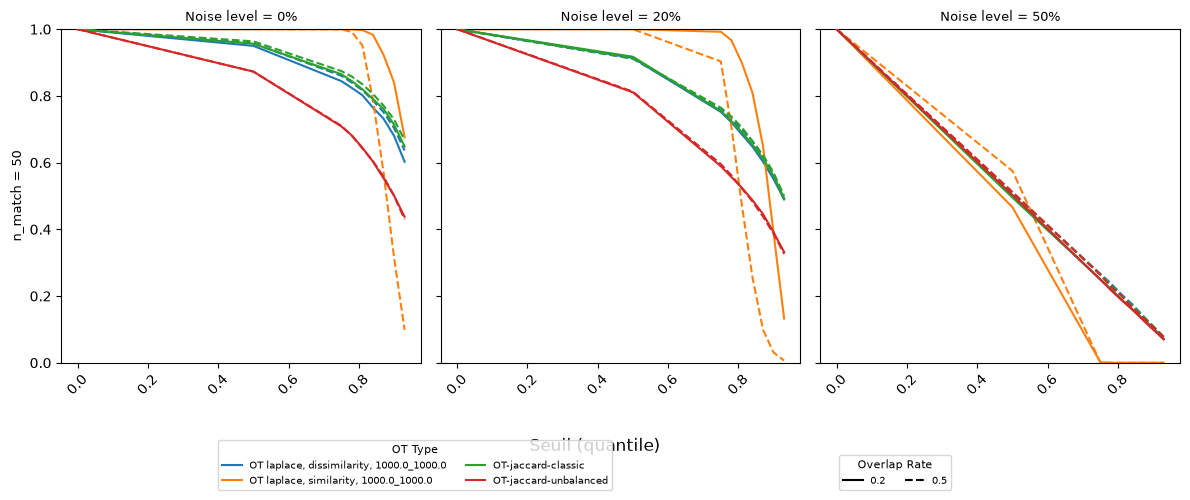

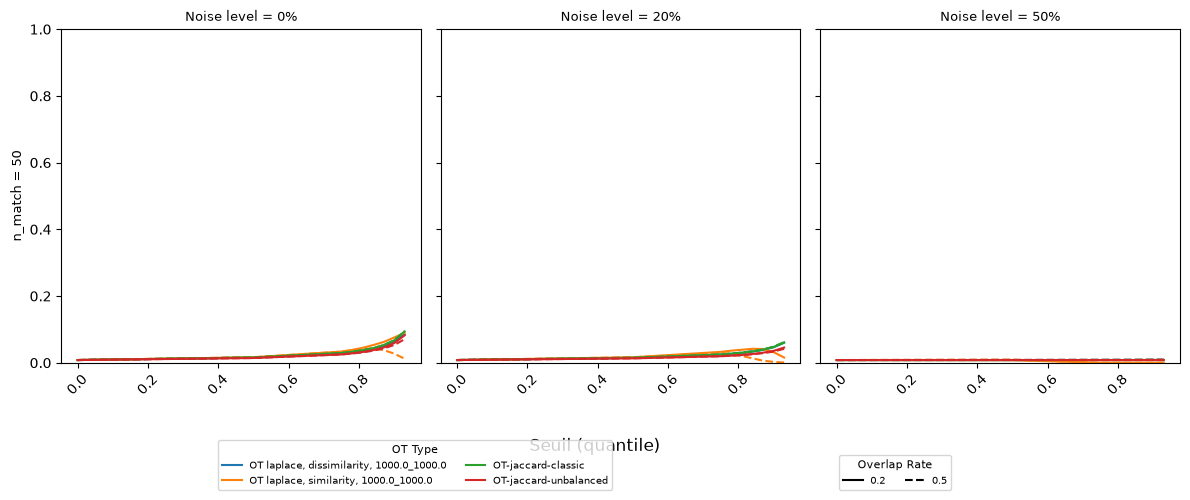

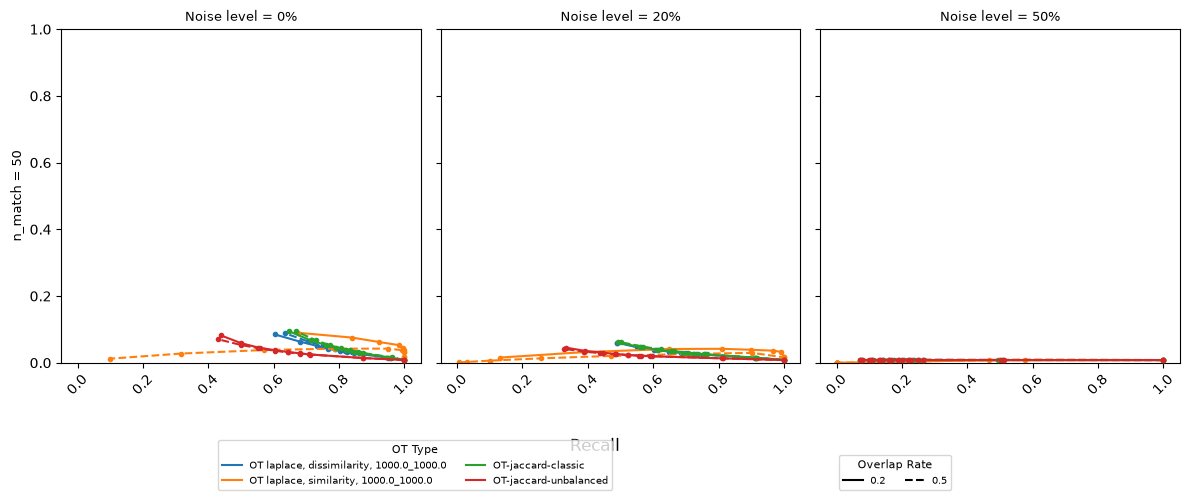

In [34]:
# Rappel vs seuil (ton graphe d'origine)
fig1 = plot_faceted_metric(
    data_long_recall, x_col="Quantile", y_col="Recall",
    x_label="Seuil (quantile)"
)

# Précision vs seuil (si tu veux la même chose pour Precision)
fig2 = plot_faceted_metric(
    data_long, x_col="Quantile", y_col="Precision",
    x_label="Seuil (quantile)"
)

# Courbe précision-rappel : x = Recall, y = Precision
fig3 = plot_faceted_metric(
    data_pr, x_col="Recall", y_col="Precision",
    x_label="Recall",
    sort_by="Quantile",
    marker="o"
)
plt.show()